
Bizim elimizde haftalık ChatGPT Google Trends verisi var. Toplam **157 hafta**.

Amaç şu:

> Geçmiş verilere bakıp gelecekteki değerleri tahmin edebilecek bir model kurmak.

Bir modelin gerçekten iyi olup olmadığını anlamak için ona bütün veriyi veremeyiz. Çünkü sonra “geleceği tahmin et” dediğimizde zaten o geleceği görmüş olur.

Bu yüzden veriyi iki parçaya ayırdık:

* **Train** = modelin öğreneceği geçmiş bölüm
* **Test** = modelin hiç görmeyeceği, sonradan tahmin etmeye çalışacağı bölüm

Bizde:

```text
145 hafta → TRAIN
12 hafta  → TEST
```

Yani model 145 haftayı görecek, sonra “peki sonraki 12 hafta ne olurdu?” diye denenecek.

Senin çıktındaki:

```text
Train son tarih: 2026-05-03
Test ilk tarih: 2026-05-10
```

şu demek:

```text
... geçmiş geçmiş geçmiş | gelecek gelecek gelecek
                        ↑
                 burada ayırdık
```

Ve güzel olan şu: tarihler birbirini takip ediyor. Arada kopukluk yok.

Şimdi bahsettiğim **baseline** terimi ne?

Baseline = **karşılaştırma için kullandığımız çok basit tahmin yöntemi**.

Mesela sen diyelim ki son 10 haftanın verisine bakıyorsun ve son gördüğün değer `72`.

Hiç model kurmadan şöyle diyebilirsin:

> “Ben bir şey bilmiyorum, o zaman bundan sonraki haftalar da yaklaşık 72 olsun.”

Bu çok basit tahmine **naive baseline** diyoruz.

Yani:

```text
Son bilinen değer = 72

Tahmin:
1. hafta → 72
2. hafta → 72
3. hafta → 72
4. hafta → 72
...
```

Bunu neden yapıyoruz?

Çünkü ileride ARIMA veya Prophet kurduğumuzda şunu soracağız:

> “Bu gelişmiş model, bu basit 72-72-72 tahmininden gerçekten daha iyi mi?”

Eğer değilse, gelişmiş modelin pek anlamı yok.

Bir de **MAE** ve **RMSE** demiştim. Onlara daha gelmedik; şimdilik sadece isimlerini duydun. İkisi de:

> “Tahminlerimiz gerçek değerlerden ne kadar sapmış?”

sorusuna cevap veren hata ölçüleri.

Şu an senden istediğim tek şey şu zihinsel modeli oturtman:

```text
TRAIN = modelin ders çalıştığı kısım
TEST = modelin sınava girdiği kısım
BASELINE = sınav için çok basit referans tahmin
```

Biz şu ana kadar sadece **train/test ayırdık**. Henüz gerçek bir model kurmadık. Baseline’a da daha başlamadık.


In [1]:
import pandas as pd

clean_data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_clean.csv",
    index_col="date",
    parse_dates=["date"],
)

In [2]:
chatgpt = clean_data["chatgpt"]

In [3]:
test_size = 12

train = chatgpt.iloc[:-test_size] #son 12 gözlem hariç her şeyi al. #modelin öğreneceği geçmiş bölüm
test = chatgpt.iloc[-test_size:] # son 12 gözlemi al. # modelin hiç görmeyeceği, sonradan tahmin etmeye çalışacağı bölüm

In [4]:
print("Train:", len(train))
print("Test:", len(test))

print("Train son tarih:", train.index[-1])
print("Test ilk tarih:", test.index[0])

Train: 145
Test: 12
Train son tarih: 2026-05-03 00:00:00
Test ilk tarih: 2026-05-10 00:00:00


Baseline dediğimiz şey, daha gelişmiş modellere geçmeden önce kullandığımız çok basit referans tahmin. Biz ilk olarak naive baseline kullanacağız.

Mantığı şu:

“Ben geleceği bilmiyorum; o zaman en son gördüğüm değeri, gelecek için tahmin olarak kullanayım.”

Örnek:

Train'in son değeri: 72

Tahmin edilen 12 hafta:
72
72
72
72
...

Yani model aslında hiçbir karmaşık şey öğrenmiyor. Sadece son bilinen değeri tekrar ediyor.

İlk olarak train’in son değerini alalım:

In [5]:
last_value = train.iloc[-1] #train serisinin en son elemanını al.

last_value

np.int64(73)

In [6]:
naive_baseline_prediction= pd.Series(
     index= test.index, data= last_value
)

naive_baseline_prediction

date
2026-05-10    73
2026-05-17    73
2026-05-24    73
2026-05-31    73
2026-06-07    73
2026-06-14    73
2026-06-21    73
2026-06-28    73
2026-07-05    73
2026-07-12    73
2026-07-19    73
2026-07-26    73
dtype: int64

Şimdi gerçek test değerleri ile tahminleri yan yana koyacağız:

In [7]:
comparison= pd.DataFrame(
    {
        "actual": test, # gerçekten gerçekleşen Google Trends değeri
        "baseline": naive_baseline_prediction # bizim basit tahminimiz
    }
)

comparison

,actual,baseline
date,,
2026-05-10,72,73
2026-05-17,73,73
2026-05-24,70,73
2026-05-31,74,73
2026-06-07,71,73
2026-06-14,70,73
2026-06-21,68,73
2026-06-28,65,73
2026-07-05,65,73


Bu tablo çok önemli çünkü artık şu soruyu sorabiliyoruz:

Tahminler gerçek değerlerden ne kadar uzak?

İşte bir sonraki adımda MAE ve RMSE tam olarak bunu ölçecek.

# MAE = Mean Absolute Error (ortalama mutlak hata.)

Mantığı şu: her hafta için

|actual - prediction|

hesaplıyoruz.

Mesela:

72 ile 73 farkı → 1
73 ile 73 farkı → 0
70 ile 73 farkı → 3
74 ile 73 farkı → 1

Sonra bütün bu farkların ortalamasını alıyoruz.

Yani MAE bize şunu söylüyor:

**“Tahminlerimiz gerçek değerlerden ortalama kaç puan sapıyor?”**

Bunu hesaplamak için **sklearn** kullanabiliriz:

from sklearn.metrics import mean_absolute_error

## Scikit-learn:

makine öğrenmesi ve model değerlendirme için kullanılan bir kütüphane. İçinde örneğin model kurma, veriyi bölme, tahminleri değerlendirme ve MAE/RMSE gibi hata ölçülerini hesaplama araçları var.

### metrics: 

Scikit-learn'ün model sonuçlarını ölçmeye yarayan bölümü. Model ne kadar iyi tahmin etmiş?
Bunu ölçmek için çeşitli metrics kullanıyoruz.

Sonra:

mae = mean_absolute_error(
    test,
    baseline_prediction,
)

mae

Buradaki yeni şey mean_absolute_error() fonksiyonu. **İlk parametre gerçek değerler, ikinci parametre tahminler.**

In [10]:
from sklearn.metrics import mean_absolute_error

In [11]:
mae = mean_absolute_error(
       test,naive_baseline_prediction
     ) # # y_true yerine gerçek test verinizi, y_pred yerine tahmininizi yazın

mae

4.166666666666667

Evet, baseline modelimizin **MAE değeri ≈ 4.17** çıktı.

Bu şu anlama geliyor:

> Son değeri (`73`) sürekli tahmin eden baseline modelimiz, gerçek ChatGPT Google Trends değerlerinden **hafta başına ortalama yaklaşık 4.17 puan sapıyor.**

Buradaki `4.17` **%4.17 değil**. Google Trends'in normalize edilmiş 0–100 ölçeğinde yaklaşık **4.17 puanlık ortalama hata**.

Örneğin bazı hatalarımız şöyle olabilir:

```text
Gerçek   Tahmin   Mutlak hata
72       73       1
73       73       0
70       73       3
65       73       8
```

Bunların tamamının ortalaması alınınca `4.17` elde ettik.

Şimdi ikinci hata ölçümüz **RMSE**.

# RMSE

RMSE = **Root Mean Squared Error**
Türkçesi: **Kök Ortalama Kare Hata**.

MAE ile aynı temel soruyu soruyor:

> “Tahminler gerçeklerden ne kadar uzak?”

Ama farkı şu: **büyük hataları daha fazla cezalandırıyor.**

Mesela hata değerlerimiz:

```text
1, 2, 3, 8
```

olsun.

MAE bunların büyüklüklerine daha düz yaklaşırken, RMSE hesaplama sırasında hataları **karesini aldığı için**:

```text
1 → 1
2 → 4
3 → 9
8 → 64
```

`8` gibi büyük bir hata çok daha fazla ağırlık kazanıyor.

Bu yüzden:

* **MAE** → “Ortalama olarak kaç puan yanılıyorum?”
* **RMSE** → “Özellikle büyük hatalarım ne kadar ciddi?”

Şimdi Scikit-learn'den şu fonksiyonu alacağız:

```python
from sklearn.metrics import root_mean_squared_error
```

Buradaki `root_mean_squared_error`, RMSE'yi doğrudan hesaplayan hazır fonksiyon.

Sonra:

```python
rmse = root_mean_squared_error(
    test,
    baseline_prediction,
)

rmse
```

çalıştır. **MAE 4.17 ile RMSE'yi yan yana yorumlayacağız.**


In [12]:
from sklearn.metrics import root_mean_squared_error

In [14]:
rmse = root_mean_squared_error(
    test,
    naive_baseline_prediction,
)

rmse

5.049752469181039

Evet, sonuçlar mantıklı:

* **MAE = 4.17**
* **RMSE = 5.05**

İkisini yan yana şöyle okuyacağız:

> Naive baseline modelimiz gerçek Google Trends değerlerinden ortalama yaklaşık **4.17 puan** sapıyor.

RMSE’nin **5.05 ile MAE’den daha yüksek olması**, bazı haftalarda ortalamadan belirgin şekilde daha büyük hatalar yaptığımızı gösteriyor. Çünkü RMSE büyük hataları daha fazla önemser.

Mesela iki model düşün:

```text
Model A hataları: 4, 4, 4, 4
Model B hataları: 1, 1, 1, 9
```

İkisinin ortalama hatası birbirine yakın olabilir. Ama Model B’de `9` gibi büyük bir hata var. RMSE bunu daha fazla cezalandırır.

Bizim durumda:

```text
MAE  = 4.17  → tipik/ortalama hata
RMSE = 5.05  → büyük hataları da dikkate alan hata
```

Ve yine: bunlar **%4.17 ve %5.05 değil**, Google Trends’in 0–100 normalize edilmiş ölçeğinde puan.

Şimdi baseline değerlendirmesini tamamlamak için hangi haftada en büyük hatayı yaptığını görelim:

```python
absolute_errors = (
    test - naive_baseline_prediction
).abs()

absolute_errors
```

Bu her hafta için:

```text
|gerçek değer - 73|
```

hesaplayacak.

Ardından:

```python
absolute_errors.max()
```

en büyük hatanın **kaç puan** olduğunu,

```python
absolute_errors.idxmax()
```

ise o en büyük hatanın **hangi tarihte** olduğunu gösterecek.

Bunları çalıştır. Sonra baseline’ımızın sonuçlarını tek cümlede özetleyip **gerçek değerler ve baseline tahminini grafikte karşılaştıracağız**; ardından gerçek tahmin modeline geçmeye hazır olacağız.


In [ ]:
absolute_errors = (
    test - naive_baseline_prediction
).abs()



pandas.Series

In [18]:
absolute_errors.max()


np.int64(8)

In [19]:
absolute_errors.idxmax()

Timestamp('2026-06-28 00:00:00')

MAE             = 4.17
RMSE            = 5.05
En büyük hata   = 8
En büyük hata tarihi = 2026-06-28

Gerçek değerlerle baseline tahminimizi grafikte görelim. Bu bize 73 sabit tahmininin nerelerde iyi, nerelerde kötü kaldığını görsel olarak gösterecek:

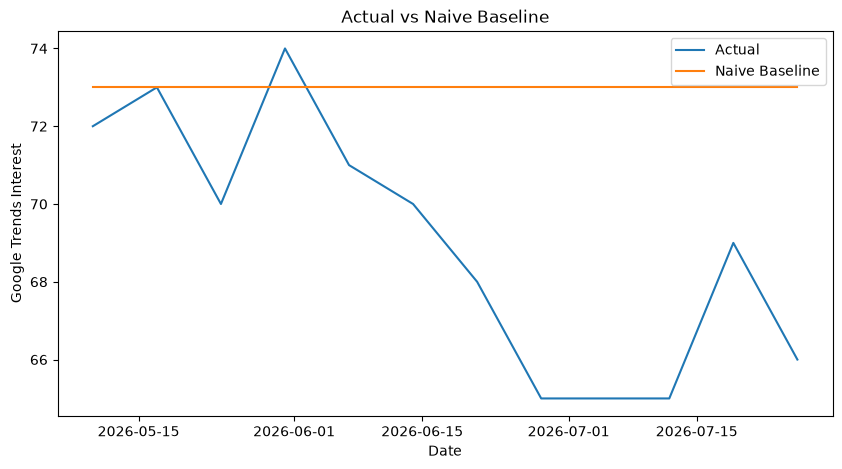

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    test.index,
    test,
    label="Actual", #çizginin adını belirliyor.
)

plt.plot(
    naive_baseline_prediction.index,
    naive_baseline_prediction,
    label="Naive Baseline",
)

plt.title("Actual vs Naive Baseline")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend() # grafikte hangi çizginin Actual, hangisinin Baseline olduğunu gösteren küçük açıklama kutusunu çıkarıyor.
plt.show()

Grafik tam beklediğimiz gibi. Burada turuncu çizginin dümdüz `73` olmasının nedeni naive baseline’ın yaptığı tek şeyin **train’de gördüğü son değeri gelecekte tekrar etmek** olması.

Mavi çizgi ise gerçek test verimiz. İlk birkaç hafta 73 civarında olduğu için baseline fena görünmüyor. Ama haziran ortasından sonra gerçek ilgi `70 → 68 → 65` şeklinde düşerken baseline hâlâ `73` diyor. Bu yüzden hata büyüyor. 28 Haziran’daki `65` ile `73` arasındaki **8 puanlık fark** da az önce bulduğumuz maksimum hata.

Yani baseline hakkında artık şunu söyleyebiliriz:

> Naive baseline, son bilinen değeri sabit tahmin ederek test döneminde MAE ≈ 4.17 ve RMSE ≈ 5.05 elde etti. Gerçek seri aşağı yönlü hareket etmeye başladığında sabit tahmin bu değişime uyum sağlayamadı.

Bu bizim **referans noktamız**. Bundan sonra kuracağımız gerçek model için hedef şu olacak:

```text
MAE  < 4.17
RMSE < 5.05
```

Daha düşük hata = baseline’dan daha iyi tahmin.

### Şimdi gerçek modele: ARIMA

Koda geçmeden önce ARIMA’nın ne olduğunu anlayalım.

**ARIMA**, zaman serilerinin geçmiş davranışından yararlanarak geleceği tahmin eden klasik bir istatistiksel modeldir.

İsminin üç parçası var:

```text
AR + I + MA
```

**AR = AutoRegressive**

Basitçe:

> “Bugünkü değer, geçmişteki değerlerle ilişkili olabilir.”

Mesela ChatGPT ilgisi geçen haftalarda:

```text
69 → 71 → 72 → 73
```

gidiyorsa, sonraki değeri tahmin ederken önceki haftaları dikkate almak mantıklı olabilir.

**I = Integrated**

Bu biraz farklı. Zaman serisinde güçlü bir yükseliş veya düşüş varsa bazen doğrudan değerler yerine **değerlerin birbirine göre değişimine** bakarız.

Örneğin:

```text
Değerler:
60 → 65 → 70 → 75

Haftalık değişimler:
   +5   +5   +5
```

Serinin kendisi sürekli yükseliyor ama değişim çok düzenli. ARIMA gerektiğinde seriyi bu şekilde farklara dönüştürerek daha modellenebilir hale getirebilir.

**MA = Moving Average**

Buradaki “moving average”, Day 3’te konuşabileceğimiz basit hareketli ortalamayla birebir aynı anlamda düşünülmemeli. ARIMA’daki MA kısmı:

> Önceki tahmin hatalarının mevcut tahmin üzerinde bilgi taşıyıp taşımadığına

bakar.

Dolayısıyla ARIMA aslında kabaca:

```text
Geçmiş değerler
      +
serideki değişim
      +
geçmiş tahmin hataları
      ↓
gelecek tahmini
```

yapmaya çalışıyor.

ARIMA’yı genellikle şöyle görürsün:

```text
ARIMA(p, d, q)
```

Buradaki `p`, `d`, `q` değerlerini ezberlemeyelim; onları seçmeye geldiğimizde **tek tek ne anlama geldiklerini ve nasıl belirlendiklerini** öğreneceğiz.

Şu anda bilmen gereken tek şey:

> Baseline sadece “son değer 73, gelecekte de 73” dedi.
> ARIMA ise geçmişteki zaman yapısını gerçekten öğrenmeye çalışacak.

Bir sonraki adımımız **hemen ARIMA kurmak değil**. Önce ARIMA için çok önemli olan **stationarity (durağanlık)** kavramını anlayacağız ve ChatGPT serimizin durağan olup olmadığına bakacağız. Çünkü `d` değerinin neden var olduğunu ancak bunu anlayınca doğru oturtabiliriz.


Şimdi ARIMA’dan önce **stationarity (durağanlık)** kavramını oturtacağız.

Bir zaman serisi kabaca durağansa, zaman geçtikçe davranışının temel özellikleri çok değişmez. Mesela ortalama seviyesi sürekli yukarı doğru kaçmaz, dalgalanma büyüklüğü de aşırı değişmez.

Örnek düşün:

```text
50, 52, 49, 51, 48, 52, 50...
```

Bu seri sürekli yaklaşık `50` civarında dolaşıyor. Durağanlığa daha yakın.

Ama:

```text
10, 15, 20, 25, 30, 35, 40...
```

sürekli yükseliyor. Bunun ortalama seviyesi zamanla değişiyor. Bu yüzden durağan değil.

Bizim ChatGPT grafiğini hatırla: 2023’ten 2026’ya kadar genel olarak ciddi bir yükseliş vardı. Bu nedenle **ham ChatGPT serisinin durağan olmamasını bekliyoruz**.

ARIMA bunu neden önemsiyor? Çünkü AR ve MA kısımları geçmişteki ilişkilerin gelecekte de benzer biçimde devam edeceği varsayımıyla daha sağlıklı çalışır. Seri sürekli başka bir seviyeye kayıyorsa bu ilişkileri öğrenmek zorlaşır.

İşte ARIMA’daki:

```text
ARIMA(p, d, q)
         ↑
         d
```

burada devreye giriyor.

`d`, kaç kez **differencing (fark alma)** yaptığımızı ifade ediyor.

Örneğin:

```text
Orijinal:
10 → 15 → 20 → 25 → 30

Birinci fark:
     5 →  5 →  5 →  5
```

Yani:

```text
bugünkü değer - önceki değer
```

hesaplanıyor.

Pandas’ta bunu yapan fonksiyon:

```python
.diff()
```

Mesela bizim train verimizde:

```python
train.diff().head()
```

çalıştırabilirsin.

İlk satırın `NaN` çıkması normal. Çünkü ilk değerin öncesinde karşılaştırılacak bir hafta yok.

Ama sadece gözümüzle “durağan gibi” demek istemiyoruz. Bunun için istatistiksel bir test de kullanacağız: **ADF testi — Augmented Dickey-Fuller test**.

Bunu `statsmodels` içinde kullanacağız:

```python
from statsmodels.tsa.stattools import adfuller
```

Buradaki yapı:

```text
statsmodels
    ↓
tsa
    ↓
stattools
    ↓
adfuller
```

`stattools`, zaman serileriyle ilgili istatistiksel test ve araçların bulunduğu modül.

Şimdilik sadece şu ikisini çalıştır:

```python
train.diff().head()
```

ve ardından:

```python
train.plot()
```

İlkinde haftadan haftaya değişimin neye benzediğini, ikincisinde de ham train serisindeki uzun vadeli yükselişi göreceğiz. Ondan sonra ADF testini yapıp “durağan mı değil mi?” kararını birlikte okuyacağız.


# ARIMA (daha basit anlatım)

ARIMA, zaman serisi verilerini analiz etmek ve geleceğe yönelik tahminler yapmak için kullanılan, istatistik tabanlı en köklü ve en popüler tahmin modellerinden biridir.
Açılımı AutoRegressive Integrated Moving Average (Otomatik Regresif Entegre Hareketli Ortalama) olan bu model, adını aldığı üç farklı matematiksel bileşenin birleşmesiyle çalışır.
Amacı, bir verinin sadece kendi geçmişine, trendine ve geçmişteki tahmin hatalarına bakarak geleceği tahmin etmektir. Yani dışarıdan başka hiçbir değişkene (hava durumu, dolar kuru vb.) ihtiyaç duymaz; sadece kendi geçmiş verisini inceler.

------------------------------
## ARIMA’nın 3 Sihirli Bileşeni (A-R-I-M-A)
ARIMA modeli kurulurken (p, d, q) şeklinde 3 tane parametre belirlenir. Bu harfler modelin üç ana parçasını temsil eder:
## 1. AR (AutoRegressive - Otomatik Regresif) → Parametresi: p

* Nedir? Verinin geçmişteki değerlerine (gecikmelerine/lags) bakarak bugünü tahmin etme kısmıdır.
* Mantığı: "Dün ve önceki gün ne olduysa, bugün de ona benzer bir şey olacak" mantığıyla çalışır. Örneğin, dün yapay zeka aramaları çok yüksekse bugün de yüksek olma eğilimindedir. p sayısı, geçmişe doğru kaç güne/aya bakılacağını belirler.

## 2. I (Integrated - Entegre/Fark Alma) → Parametresi: d

* Nedir? Veriyi durağan (stationary) hale getirmek için yapılan "fark alma" işlemidir.
* Mantığı: ARIMA modelinin doğru çalışabilmesi için verinin ortalamasının ve varyansının zaman içinde sabit olması (yani yukarı veya aşağı doğru sürekli giden sert bir trendinin olmaması) gerekir. Eğer verinizde sürekli yükselen bir trend varsa (sizin Google Trend yapay zeka veriniz gibi), bugünün değerinden dünün değerini çıkararak trendi yok edersiniz. d sayısı, bu fark alma işleminin kaç kez yapılacağını belirtir.

## 3. MA (Moving Average - Hareketli Ortalama) → Parametresi: q

* Nedir? Geçmişte yapılan tahmin hatalarının (şokların/gürültülerin) bugünkü tahmine olan etkisini ölçer.
* Mantığı: Sistemdeki ani dalgalanmaları ve şokları yumuşatır. Örneğin, geçen hafta aniden patlayan bir yapay zeka haberi veride ani bir sıçrama (hata) yarattıysa, MA bileşeni bu hatanın etkisinin sonraki günlere nasıl yansıyacağını hesaplar. q sayısı, geçmişteki kaç hatanın hesaba katılacağını belirler.

------------------------------
## Sizin Projeniz İçin ARIMA Neden Önemli?
Sizin projenizdeki naive_baseline modeli sadece en son değere bakıyordu ve gelecekteki trendi göremiyordu. ARIMA ise:

* Google Trend verinizdeki genel yükseliş veya düşüş trendini (I kısmı ile) algılar.
* Geçmiş haftaların birbirini nasıl etkilediğini (AR kısmı ile) çözer.
* Böylece düz bir çizgi çizmek yerine, verinizin ruhuna uygun, çok daha gerçekçi ve dalgalı bir gelecek tahmini üretir.



* Verimizin durağan olup olmadığını anlamak için önce ADF (Augmented Dickey-Fuller) testi yapıyoz.




In [21]:
train.diff().head()

date
2023-07-30    NaN
2023-08-06    1.0
2023-08-13    0.0
2023-08-20    1.0
2023-08-27    1.0
Name: chatgpt, dtype: float64

In [23]:
train.diff().tail()

date
2026-04-05    0.0
2026-04-12    1.0
2026-04-19    3.0
2026-04-26   -2.0
2026-05-03    2.0
Name: chatgpt, dtype: float64

<Axes: xlabel='date'>

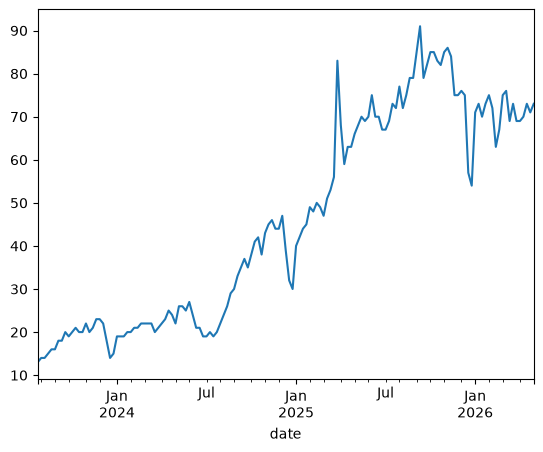

In [22]:
train.plot()

# ADF = Augmented Dickey-Fuller. 

ADF (Augmented Dickey-Fuller) testi, bir zaman serisinin durağan (stationary) olup olmadığını anlamak için kullanılan istatistiksel bir kontrol aracıdır.
Zaman serisi analizlerinde, özellikle ARIMA gibi geleneksel modelleri kullanmadan önce verinin durağan olup olmadığını bilmek hayati önem taşır. ADF testi de bize tam olarak bu durumun matematiksel raporunu verir.

------------------------------
## Durağanlık (Stationarity) Nedir? Neden Önemlidir?
Bir zaman serisinin durağan olması, verinin ortalamasının, varyansının (dalgalanma boyutu) ve zaman içindeki yapısının sabit kalması demektir.

* Durağan Olmayan Veri (Uçak gibi): Sürekli yukarı doğru yükselen bir trendi vardır (Örn: Sizin 3 yıllık yapay zeka Google Trend veriniz). Geçmişteki ortalaması 30 iken, bugün 80 olmuştur.
* Durağan Veri (Kalp atışı gibi): Belirli bir çizgi (ortalama) etrafında sürekli yukarı aşağı dalgalanır ama ne yukarı doğru kaçar ne aşağı doğru çöker.

Neden önemli? ARIMA gibi modeller, verinin gelecekte de geçmişteki ortalama ve kurallarla hareket edeceğini varsayar. Eğer veri durağan değilse, model yanıltıcı ve yanlış tahminler (Spurious Regression) üretir.

------------------------------

## ADF Testi Nasıl Çalışır? (Hipotezler)
ADF testi arka planda bir hipotez testi yürütür ve size bir p-değeri (p-value) verir:

* H0 (Boş Hipotez): Seri durağan değildir (Birim kök vardır, trend içerir).
* H1 (Alternatif Hipotez): Seri durağandır.

Sizin kodda bakacağınız tek şey p-değeri (p-value) olacaktır:

* Eğer p-değeri ≤ 0.05 ise: Tebrikler, veriniz durağandır. ARIMA modelinde fark alma parametresini d=0 yapabilirsiniz.
* Eğer p-değeri > 0.05 ise: Veriniz durağan değildir. ARIMA'da trendi yok etmek için fark almanız gerekir (d=1 veya d=2).

------------------------------

Bu testte temel soru şu:

Bu zaman serisinde durağan olmamaya işaret eden bir yapı var mı?

Test bize özellikle bir p-value verecek. Şimdilik karar kuralını şöyle düşün:

* p-value < 0.05  → durağan olduğuna dair yeterli kanıt var
* p-value >= 0.05 → durağan diyemiyoruz

Şimdi önce ham train serisine test uygulayalım:

In [24]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train)

adf_result

(np.float64(-0.9544902016340422),
 np.float64(0.7694991558514677),
 2,
 142,
 {'1%': np.float64(-3.477261624048995),
  '5%': np.float64(-2.8821181874544233),
  '10%': np.float64(-2.5777431104939494)},
 np.float64(767.9614641444493))

In [ ]:
adf_statistic = adf_result[0] #[0] test istatistiğini
p_value = adf_result[1] # [1] ise p-value değerini alıyor.

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)

ADF Statistic: -0.9544902016340422
p-value: 0.7694991558514677


ADF testinde temel varsayım, yani null hypothesis (H₀) şudur:

Seri durağan değildir; seride unit root vardır.

Biz karar verirken genelde 0.05 sınırını kullanıyoruz:

* p-value < 0.05   → H₀ reddedilir → durağanlık lehine kanıt var
* p-value >= 0.05  → H₀ reddedilemez → durağan diyemeyiz

Senin sonucun:

p-value = 0.7695

0.7695 > 0.05 olduğu için **ham train serisini durağan kabul edemiyoruz.**

In [ ]:
differenced_train = train.diff().dropna() #her haftadan önceki haftayı çıkarıyor. ilk satırda oluşan NaNı kaldırıyor. ADF testi NaN içeren seriyle çalışamaz.

Sonra fark alınmış seriye ADF uygulayalım:

In [27]:
adf_diff_result = adfuller(differenced_train)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

ADF Statistic: -12.155582728136798
p-value: 1.5348088381376744e-22



Bizim asıl amacımız `d` bulmak değil. Asıl amacımız:

> **ARIMA’ya mümkün olduğunca durağan bir seri vermek.**

Durağanlık neden önemli? Çünkü ARIMA geçmişte gördüğü ilişkilerin gelecekte de benzer biçimde devam edeceğini varsayarak çalışıyor. Ama serinin seviyesi sürekli değişiyorsa bu ilişkiyi öğrenmek zorlaşıyor.

Mesela şöyle bir seri düşün:

```text
10, 11, 10, 12, 11, 10, 12...
```

Bu seri yaklaşık aynı bölgede dolaşıyor. Ortalama seviyesi kabaca aynı. Geçmişteki davranışı geleceğe taşımak daha anlamlı.

Ama şöyleyse:

```text
10, 20, 30, 40, 50, 60...
```

seri sürekli başka bir seviyeye gidiyor. “Geçmişte ortalama 20 civarındaydı” bilgisi gelecekte pek işe yaramıyor.

İşte **differencing**, yani fark alma, bu yükselişi kaldırmaya çalışıyor.

Şu seri:

```text
10 → 20 → 30 → 40 → 50
```

bir kez fark alınca:

```text
20 - 10 = 10
30 - 20 = 10
40 - 30 = 10
50 - 40 = 10
```

yani:

```text
10, 10, 10, 10
```

haline geliyor.

Artık “değerin kendisi kaç?” yerine:

> **“Haftadan haftaya ne kadar değişiyor?”**

sorusuna bakıyoruz.

Bizim ChatGPT verisinde yaptığımız tam olarak buydu.

Önce ham seri:

```python
adfuller(train)
```

sonucu:

```text
p = 0.7695
```

ADF testinin başlangıç varsayımı:

> **H₀: Seri durağan değildir.**

`0.7695 > 0.05` olduğu için elimizde bu varsayımı reddedecek yeterli kanıt yok.

Yani:

> “Ham seri durağandır diyemiyoruz.”

Bu zaten grafikten de mantıklıydı çünkü ChatGPT ilgisi zamanla yaklaşık 15'lerden 70'lere çıkmıştı.

Sonra:

```python
train.diff()
```

ile bir kez fark aldık.

Bu yüzden:

```text
d = 1
```

adayını denemiş olduk.

Fark alınmış seriye tekrar ADF yaptık:

```text
p ≈ 0.000000000000000000000153
```

Bu sefer:

```text
p < 0.05
```

dolayısıyla:

> “Seri durağan değildir” varsayımını reddediyoruz.

Yani **birinci fark alınmış seri durağan görünüyor.**

Bu nedenle:

```text
ARIMA(p, 1, q)
         ↑
         d = 1
```

diyoruz.

Senin söylediğini daha kesin biçimde yazarsak:

```text
Ham seri
↓
ADF
↓
p > 0.05
↓
Durağan diyemiyoruz
↓
1 kez fark al
↓
ADF'yi tekrar yap
↓
p < 0.05
↓
Fark alınmış seri durağan
↓
d = 1
```

Ve evet: **Eğer ham seride daha baştan `p < 0.05` çıksaydı**, fark almaya gerek duymayacaktık ve ilk adayımız:

```text
d = 0
```

olacaktı.

Ama önemli ince nokta şu: `d`, doğrudan “p-value kaç çıktı?” demek değil. `d`:

> **Seriyi durağanlaştırmak için kaç kez fark aldık?**

demek.

ADF testi ise bize:

> **“Şu anki hali durağan görünüyor mu?”**

diye kontrol sağlıyor.

Yani ADF **kontrol aracı**, `d` ise **yaptığımız fark alma sayısı**.

Bunu anladıysan ARIMA’daki `d` kısmını gerçekten anlamış oldun; sonraki `p` ve `q` biraz daha farklı mantıkta.


# ACF ve PACF

ACF (Autocorrelation Function - Otokorülasyon Fonksiyonu) ve PACF (Partial Autocorrelation Function - Kısmi Otokorülasyon Fonksiyonu), zaman serisi verilerinde geçmiş ile bugün arasındaki ilişkiyi (bağlantıyı) çözen ve ARIMA modelinin parametrelerini (p ve q) belirlemek için kullanılan iki güçlü grafiksel analiz aracıdır.

Zaman serilerinde "Otokorülasyon", bir verinin kendi geçmiş değerleriyle olan korelasyonu (ilişkisi) anlamına gelir.

* lag = geçmişe kaç adım baktığımız.

Haftalık veride:

lag 1 → 1 hafta önce
lag 2 → 2 hafta önce
lag 3 → 3 hafta önce

Örneğin bu haftaki değişimin geçen haftaki değişimle ilişkisi varsa lag 1 ilişkisi vardır.

------------------------------
## 1. ACF (Otokorülasyon Fonksiyonu) Nedir?

* Mantığı: Bir zaman serisinin bugünkü değeri ile geçmişteki tüm gecikmeleri (1 adım öncesi, 2 adım öncesi, 3 adım öncesi...) arasındaki doğrudan ve dolaylı toplam ilişkiyi ölçer.

* Dolaylı İlişki Ne Demek? Bugünün verisi dünden etkilenir. Dünün verisi de on önceki günden etkilenmişti. Dolayısıyla bugünün verisi, iki gün önceki veriden dünün aracılığıyla dolaylı olarak da etkilenir. ACF bu zincirleme etkilerin tamamını gösterir.

* Ne İşe Yarar? ARIMA modelindeki MA (Moving Average) bileşeninin yani q parametresinin kaç olması gerektiğini bulmamızı sağlar.



------------------------------
## 2. PACF (Kısmi Otokorülasyon Fonksiyonu) Nedir?

* Mantığı: Araya giren diğer tüm günlerin/adımların etkisini temizleyerek, bugünün değeri ile geçmişteki belirli bir gecikme arasındaki sadece saf (doğrudan) ilişkiyi ölçer.
* Saf İlişki Ne Demek? Bugün ile 2 gün önceki veri arasındaki ilişkiye bakarken, dünün (1 gün öncenin) yarattığı tüm gürültüyü ve aracı etkiyi matematiksel olarak sistemden çıkarır. Sadece o iki günün birbiriyle olan doğrudan bağını bırakır.
* Ne İşe Yarar? ARIMA modelindeki AR (AutoRegressive) bileşeninin yani p parametresinin kaç olması gerektiğini bulmamızı sağlar.

Mesela lag 2yi incelerken:

İki hafta önceki değer bugünkü değerle gerçekten doğrudan mı ilişkili, yoksa bu ilişki aslında bir hafta önceki değerden mi geliyor?

sorusunu ayırmaya çalışır.

------------------------------
## 📊 Grafikleri Okuma ve ARIMA Parametrelerini Seçme Kuralı

Python'da bu grafikleri çizdirdiğinizde, karşınıza mavi bir güven aralığı (gölgeli alan) ve dikey çubuklar çıkar. Mavi alanın dışına taşan çubuklar, istatistiksel olarak anlamlı bir ilişki olduğunu gösterir.

| Grafik Türü | Nasıl Davranıyor? (Kalıp) | Hangi Parametreyi Belirler? |
|---|---|---|
| PACF Grafiği | Çubuklar birkaç adım sonra aniden sıfıra düşüyorsa (Cut-off) | AR(p) modelidir. Mavi alanın dışındaki son anlamlı çubuğun sayısı p olur. |
| ACF Grafiği | Çubuklar birkaç adım sonra aniden sıfıra düşüyorsa (Cut-off) | MA(q) modelidir. Mavi alanın dışındaki son anlamlı çubuğun sayısı q olur. |

(Eğer iki grafik de aniden kesilmek yerine yavaş yavaş sönümlenerek azalıyorsa, sistemde hem AR hem MA yani karma bir ARIMA yapısı var demektir).

------------------------------

**ACF/PACF’yi ham train üzerinde değil, durağanlaştırdığımız differenced_train üzerinden inceliyeceğiz.**

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # tsaplots, zaman serisi grafiklerini oluşturan bölüm.

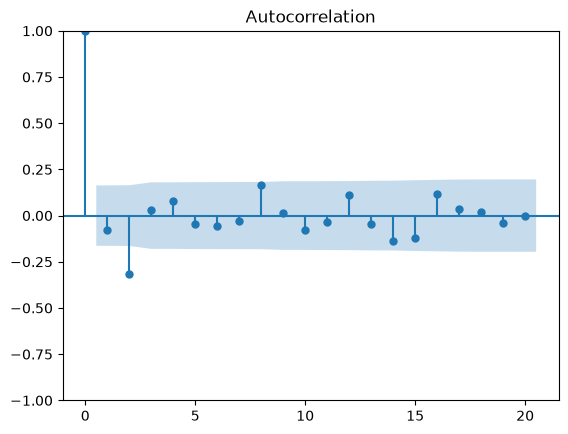

In [ ]:
# Önce ACF

plot_acf(
    differenced_train,
    lags=20, # Geçmişteki ilk 20 haftaya kadar olan ilişkileri göster.
)

plt.show()


Grafikteki her bir dikey çizgi (çubuk), verinizin geçmişteki bir zaman adımıyla olan ilişki gücünü (korelasyonunu) gösterir. Alttaki sayılar (0, 5, 10, 15, 20) ise ne kadar geçmişe gittiğimizi (buna Lag veya Gecikme denir) belirtir.

------------------------------
## Grafikte Gördüğünüz Çubuklar Ne Anlama Geliyor?

* 0 noktasındaki 1.00'e vuran çubuk: Bugünün verisinin, yine bugünün verisiyle olan ilişkisidir. Bir veri kendisiyle %100 aynı olduğu için bu çubuk her zaman en tepededir (1.00). Bunu analiz yaparken dikkate almayız.

* 1 noktasındaki çubuk: Bugünün verisi ile 1 adım öncesi (örneğin dün veya geçen ay) arasındaki ilişkidir. Çubuk aşağı doğru hafifçe uzanmış, yani negatif bir ilişki var ama çok güçlü değil.

* 2 noktasındaki aşağı doğru uzanan büyük çubuk: İşte grafiğinizdeki en önemli ipucu burasıdır. Bugünün verisi ile 2 adım öncesi arasında anlamlı ve ters (negatif) bir ilişki var. Yani 2 adım önce veri çok yüksekse, bugün sert bir şekilde düşme eğiliminde; veya tam tersi.

* Mavi Gölgeli Alan (Güven Aralığı): Bu mavi alan "istatistiksel olarak önemsiz / rastgele gürültü" bölgesidir. Çubukların uçlarındaki yuvarlak noktalar mavi alanın içinde kalıyorsa, o geçmiş günlerin bugünkü veri üzerinde kayda değer bir etkisi yok demektir. Eğer bir çubuk mavi alanı aşmışsa (2 noktasındaki gibi aşağı taşmışsa veya 8 noktasındaki gibi sınıra çok yaklaşmışsa), o günün verisi bugün üzerinde gerçek bir söz sahibidir.



------------------------------



## ACF Arkada Nasıl Çalışıyor? (Çok Basit Bir Mekanizma)

Bilgisayar bu grafiği çizerken arka planda şu basit kaydırma işlemini yapar:

   1. Orijinal Veriniz: [10, 20, 15, 30, 25, 40] olsun.

   2. 1 Adım Kaydırılmış Hali (Lag 1): Veriyi bir sağa kaydırır: [NaN, 10, 20, 15, 30, 25]. Sonra bu iki liste arasındaki benzerliği hesaplar ve grafikte 1 sayısının üzerine bir çubuk olarak çizer.

   3. 2 Adım Kaydırılmış Hali (Lag 2): Veriyi iki sağa kaydırır: [NaN, NaN, 10, 20, 15, 30]. Bu sefer orijinal veriyle bu listeyi karşılaştırır, benzerliği hesaplar ve grafikte 2 sayısının üzerine çizer.


 **bu grafik gerçekten neyi ölçüyor**, onu oturtalım.

Biz az önce şuraya gelmiştik:

```text
Ham ChatGPT serisi
→ durağan değildi

1 kere fark aldık
→ haftadan haftaya DEĞİŞİMLERİ elde ettik
→ bu seri durağan çıktı
→ d = 1
```

Yani artık elimizde örneğin şöyle bir seri olduğunu düşün:

```text
Hafta        ChatGPT     Bir önceki haftaya göre değişim
1              70
2              73              +3
3              71              -2
4              75              +4
5              72              -3
```

Biz ARIMA’ya artık şunu soruyoruz:

> “Bu haftalık değişimlerin geçmişteki değişimlerle bir bağlantısı var mı?”

İşte **ACF grafiğinin sorduğu soru tam olarak bu.**

### `lag` neydi?

`lag` = kaç hafta geriye baktığımız.

```text
lag 1 → 1 hafta önce
lag 2 → 2 hafta önce
lag 3 → 3 hafta önce
```

Mesela `lag 1` için ACF şunu araştırıyor:

> “Bu haftaki değişim ile 1 hafta önceki değişim arasında ilişki var mı?”

`lag 2`:

> “Bu haftaki değişim ile 2 hafta önceki değişim arasında ilişki var mı?”

Ve böyle devam ediyor.

Senin grafiğinin yatay eksenindeki:

```text
0  1  2  3  4 ... 20
```

bunlar **kaç hafta geriye baktığımız**.

Dikey eksen ise ilişkinin gücü:

```text
+1  → çok güçlü aynı yönlü ilişki
 0  → belirgin ilişki yok
-1  → çok güçlü ters yönlü ilişki
```

Örneğin:

```text
+0.8
```

olsaydı, “geçmişteki değişim yükseliyorsa bugünkü değişim de genellikle aynı yönde” gibi güçlü bir ilişki olurdu.

```text
-0.8
```

olsaydı, “geçmişteki değişimin tersine gitme eğilimi var” derdik.

### Peki mavi alan ne?

Burası en önemli kısım.

Gerçek verilerde tamamen tesadüfen de küçük ilişkiler görebiliriz. Mesela:

```text
0.03
-0.08
0.11
```

gibi değerler çıkması normal.

Mavi alanı kabaca:

> **“Bu kadarlık küçük ilişki tesadüften kaynaklanmış olabilir.”**

bölgesi gibi düşünebilirsin.

Dolayısıyla bir çubuk **mavi alanın içindeyse**:

> “Burada güçlü bir ilişki var diyemeyiz.”

Bir çubuk **mavi alanın belirgin şekilde dışına çıkıyorsa**:

> “Burada tesadüften daha güçlü olabilecek bir ilişki var; bunu dikkate alalım.”

diyoruz.

Şimdi senin grafiğine bakalım.

`lag 0` çok yüksek:

```text
lag 0 = 1
```

Bunu boş veriyoruz. Çünkü bu:

> “Bu haftaki değer, kendisiyle ne kadar ilişkili?”

sorusu. Cevabı doğal olarak %100.

Sonra:

```text
lag 1
```

yaklaşık `-0.08` ve mavi alanın içinde.

Yani:

> 1 hafta önceki değişimle bugünkü değişim arasında güçlü bir ilişki tespit etmiyoruz.

Ama:

```text
lag 2 ≈ -0.32
```

mavi alanın dışına çıkmış.

Bu daha ilginç.

Yani verimiz kabaca şunu söylüyor:

> **Bu haftaki değişim ile 2 hafta önceki değişim arasında ters yönlü bir ilişki olabilir.**

Mesela sadece mantığı göstermek için:

```text
2 hafta önce: +5
şimdi:        -3

2 hafta önce: -4
şimdi:        +2
```

gibi ters yönlü hareketlerin veri içinde beklenenden fazla olması buna yol açabilir.

Ama bu:

> “İki hafta önce yükseldiyse kesin bu hafta düşer.”

demek **değil**.

Sadece istatistiksel bir eğilim.

Senin grafiğinde geri kalan noktaların çoğu mavi alanın içinde. Bu da bize:

> “Fark aldıktan sonra serinin geçmişe bağlı yapısının büyük kısmı kaybolmuş; çok güçlü ve uzun süreli bir hafıza görünmüyor.”

diyor.

### Peki bunun ARIMA ile bağlantısı ne?

Şu an elimizde:

```text
ARIMA(p, 1, q)
         ↑
         bunu bulduk
```

var.

`d=1` ile trend sorununu hallettik.

Şimdi ARIMA’ya şunu öğretmeye çalışacağız:

> “Durağanlaştırılmış haftalık değişimlerin geçmişinde, geleceği tahmin etmemize yardım eden bir düzen var mı?”

ACF bunun ilk haritasını çıkarıyor.

Ama **bu grafiğe bakıp hemen `q=2` demiyoruz.**

Çünkü bir de PACF var. PACF aynı geçmiş ilişkilerine başka bir açıdan bakacak. İkisini birlikte okuyunca:

```text
ACF + PACF
     ↓
muhtemel p ve q adayları
     ↓
birkaç ARIMA modeli
     ↓
test verisinde MAE / RMSE
     ↓
hangisi gerçekten daha iyi?
```

diye ilerleyeceğiz.

Şu anda bu grafikten tek çıkarımın şu olması yeterli:

> **“Fark aldıktan sonra haftalık değişimlerin geçmişle bağlantısı var mı diye baktık. Çoğu haftada güçlü bağlantı yok; 2 hafta geride ise dikkat çekici ters yönlü bir ilişki var.”**


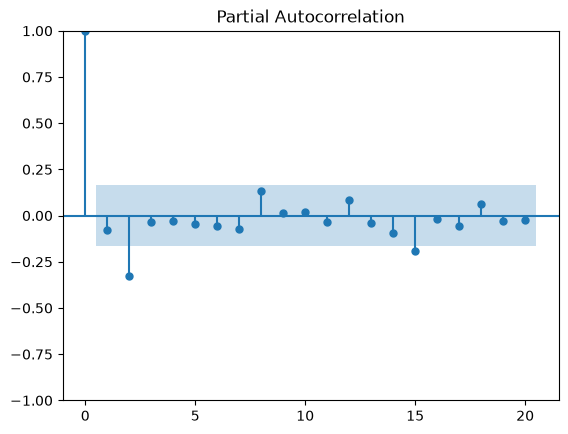

In [30]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    differenced_train,
    lags=20,
)

plt.show()


En basit anlatımla PACF, geçmişteki bir günün bugüne olan "saf ve dolaysız" etkisini ölçer. Araya giren diğer günlerin torpilini veya etkisini matematiksel olarak siler.

------------------------------

## PACF Arkada Nasıl Çalışır? (Dedikodu Benzetmesi)
Bir şirkette 3 çalışan olsun: Ahmet (2 gün önceki veri), Burak (1 gün önceki veri) ve Can (Bugünkü veri).

* ACF (Önceki Grafik) Şunu Ölçer: Ahmet bir dedikodu çıkarır, bunu Burak'a anlatır. Burak da ertesi gün Can'ya anlatır. Can bu dedikodudan etkilenir. ACF'e baktığınızda Ahmet ile Can arasında büyük bir bağ görürsünüz çünkü aradaki Burak köprüsünü de hesaba katar.

* PACF (Bu Grafik) Şunu Yapar: Burak'ı odadan çıkarır. Ahmet ile Can'ı baş başa bırakır. "Burak aradan çekildiğinde, Ahmet doğrudan Can'ı ne kadar etkiliyor?" sorusunun cevabını arar. Araya giren günlerin (aracıların) etkisini tamamen temizler.

------------------------------
## Sizin Grafiğiniz Bize Ne Anlatıyor?

Tıpkı ACF grafiğinde olduğu gibi yine mavi gölgeli alanın dışına taşan çubuklara odaklanmalıyız:

* 0 noktasındaki çubuk: Bugünün kendisiyle olan saf ilişkisidir (%100). Bunu analiz ederken eliyoruz.

* 1 noktasındaki çubuk: Dünün bugüne olan saf etkisidir. Mavi alanın içinde kalmış, yani doğrudan etkisi oldukça zayıf.

* 2 noktasındaki aşağı taşan büyük çubuk: Tıpkı ACF'te olduğu gibi, PACF'te de 2 adım öncesi (Lag 2) mavi sınırı çok net bir şekilde aşağı doğru delip geçmiş. Bu bize şunu söyler: 1 adım öncesini aradan çıkarsak bile, 2 adım önceki verinin bugün üzerinde çok güçlü, doğrudan ve negatif (ters) bir etkisi var.

* 15 noktasındaki küçük taşma: Çok gerilerde (15 adım önce) sınırın ucuna değen bir çubuk var ama bu kadar uzak bir geçmiş genellikle tesadüfi/gürültü kabul edilir, modelde dikkate alınmaz.

------------------------------

## Bu Grafik ARIMA İçin Ne Söylüyor?
PACF grafiği bize ARIMA modelinin AR (yani p) parametresini fısıldar.

* Mavi alanı net bir şekilde aşan son önemli çubuk 2 numara olduğu için, bu grafik sizin modelinizde p = 2 (veya p = 1) kullanmanız gerektiğine işaret eder.

## 🧩 Büyük Resmi Birleştirelim (ARIMA Parametreniz Çıktı!)

Şu an durumumuz şöyle:

ARIMA(p, d, q)

d = 1

Bunu ADF ile belirledik.

PACF:

lag 2 dikkat çekici
→ p için 2 aday

ACF:

lag 2 dikkat çekici
→ q için 2 aday

Ama çok önemli: bu, kesin ARIMA(2,1,2) en iyi modeldir demek değil.

ACF/PACF bize sadece “hangi küçük değerleri denemek mantıklı?” diye yol gösteriyor.

Bu yüzden bundan sonra örneğin birkaç aday deneyebiliriz:

ARIMA(2,1,0)
ARIMA(0,1,2)
ARIMA(2,1,2)
ARIMA(1,1,1)

ve her birinin test dönemindeki:

MAE
RMSE

değerlerini hesaplarız.

Sonra baseline’ımızla karşılaştırırız:

Naive baseline
MAE  = 4.17
RMSE = 5.05

**Yani artık grafiklere bakıp tahmin yürütmeyi bırakıp gerçek modelleri yarıştırma aşamasına geçiyoruz**




In [31]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
arima_model = ARIMA(
    train, # ham veri, differenced değil zaten d=1 yapçak onu
    order=(2, 1, 0), #(p, d, q)
) #şu anda model daha öğrenmedi. Sadece “hangi modeli kullanacağımızı” tanımladık.

arima_fit = arima_model.fit() # fit() modeli veriye uydurmak/eğitmek.

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [35]:
arima_210 = arima_fit.forecast( #Bu bize ARIMA(2,1,0)'ın 12 haftalık test dönemi için yaptığı tahminleri verecek.
    steps=len(test)
)

arima_210

2026-05-10    73.432823
2026-05-17    72.772806
2026-05-24    72.700356
2026-05-31    72.911593
2026-06-07    72.914312
2026-06-14    72.848617
2026-06-21    72.853910
2026-06-28    72.873768
2026-07-05    72.870273
2026-07-12    72.864448
2026-07-19    72.866074
2026-07-26    72.867727
Freq: W-SUN, Name: predicted_mean, dtype: float64

Bu çıktı çok öğretici çünkü ARIMA'nın baseline’dan neden farklı olduğunu gösteriyor ama aynı zamanda **çok da farklılaşamadığını** görüyoruz.

Baseline ne yapıyordu?

```text
73, 73, 73, 73, 73, ...
```

ARIMA(2,1,0) ise:

```text
73.43
72.77
72.70
72.91
72.91
72.85
...
```

Yani ARIMA ilk birkaç hafta geçmişteki ilişkilere göre küçük düzeltmeler yapıyor, sonra tahminler yaklaşık **72.87 civarında sabitleniyor**.

Neden? Çünkü `p=2` ile model son iki lag’den gelen bilgiyi kullanıyor ama bu etkinin ileri haftalara gittikçe gücü azalıyor. Ayrıca `q=0`; başka bir hata yapısı eklemedik. Sonuçta model uzun vadede son seviyeye yakın bir noktada dengeleniyor.

Gerçek test verimiz ise hatırlarsan aşağı doğru gidiyordu:

```text
72, 73, 70, 74, 71, 70, 68, 65, ...
```

Bu yüzden yalnız tahminlere bakarak bile ARIMA(2,1,0)'ın düşüşü pek yakalayamadığını görüyoruz.

Şimdi bunu **baseline ile aynı sınava sokacağız**. Aynı MAE ve RMSE’yi hesaplamamız önemli; aksi halde karşılaştırma adil olmaz:

```python
arima_mae = mean_absolute_error(
    test,
    arima_prediction,
)

arima_rmse = root_mean_squared_error(
    test,
    arima_prediction,
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
```

Sonra elimizde şöyle bir karşılaştırma olacak:

```text
                 MAE       RMSE
Naive           4.17       5.05
ARIMA(2,1,0)      ?          ?
```

Burada **düşük olan daha iyi**.

ARIMA’nın daha karmaşık olması onun otomatik olarak baseline’dan daha iyi olacağı anlamına gelmiyor. Hatta kötü çıkarsa bu da önemli bir sonuç: “Bu ARIMA ayarları naive yöntemden daha iyi tahmin üretmedi.”

Bu iki değeri çalıştırıp gönder; sonra **ARIMA gerçekten baseline’ı geçti mi?** ona bakalım.


In [39]:
arima_mae = mean_absolute_error(
    test,
    arima_210,
)

arima_rmse = root_mean_squared_error(
    test,
    arima_210,
)

print("ARIMA(2,1,0) MAE:", arima_mae)
print("ARIMA(2,1,0) RMSE:", arima_rmse)

ARIMA(2,1,0) MAE: 4.117325528903795
ARIMA(2,1,0) RMSE: 4.948231609916763


Güzel, ARIMA(2,1,0) baseline’ı geçmiş, ama fark küçük.

                 MAE      RMSE
Naive           4.17      5.05
ARIMA(2,1,0)    4.12      4.95

Yani ARIMA’nın hem ortalama hatası hem de büyük hatalara duyarlı RMSE’si biraz daha düşük. Bu nedenle şu an için:

ARIMA(2,1,0), naive baseline’dan biraz daha iyi tahmin yaptı.

Ama “ARIMA başarılı, bitti” diyemeyiz. Çünkü ACF/PACF’den başka mantıklı adaylarımız da vardı. Şimdi onları aynı train ve aynı test üzerinde deneyeceğiz ve hangisi daha düşük MAE/RMSE veriyor bakacağız.

Sıradaki adayımız ARIMA(0,1,2) olsun. Bunun anlamı:

p=0 → AR kısmını kullanma.
d=1 → bir kez fark al.
q=2 → MA kısmında son 2 hata gecikmesini kullan.

In [37]:
arima_012 = ARIMA(
    train,
    order=(0, 1, 2),
)

arima_012_fit = arima_012.fit()

arima_012_prediction = arima_012_fit.forecast(
    steps=len(test)
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [38]:
arima_012_mae = mean_absolute_error(
    test,
    arima_012_prediction,
)

arima_012_rmse = root_mean_squared_error(
    test,
    arima_012_prediction,
)

print("ARIMA(0,1,2) MAE:", arima_012_mae)
print("ARIMA(0,1,2) RMSE:", arima_012_rmse)

ARIMA(0,1,2) MAE: 3.8980385782341416
ARIMA(0,1,2) RMSE: 4.677279114147689


Bu daha iyi çıktı. Şu an karşılaştırma şöyle:

Model            MAE     RMSE
Naive            4.17    5.05
ARIMA(2,1,0)     4.12    4.95
ARIMA(0,1,2)     3.90    4.68

Yani şu ana kadar en iyi model ARIMA(0,1,2).

Bunu şöyle yorumlayabiliriz:

Baseline ortalama yaklaşık 4.17 puan hata yapıyordu.
ARIMA(2,1,0) bunu çok az iyileştirdi.
ARIMA(0,1,2) ise MAE’yi yaklaşık 3.90’a, RMSE’yi 4.68’e düşürdü.

Demek ki bu veri için, en azından şu test döneminde, geçmiş tahmin hatalarını dikkate alan MA kısmı, geçmiş değerleri doğrudan kullanan AR kısmından biraz daha işe yarıyor gibi görünüyor.

ARIMA(0,1,2)yi tekrar okuyalım:

p = 0 → geçmiş değerlerin AR etkisini kullanmıyor
d = 1 → seri 1 kez farklanıyor
q = 2 → son 2 hata gecikmesini dikkate alıyor

Ama burada da “q=2 kesin doğru” demiyoruz. Şimdi mantıklı bir sonraki aday ARIMA(2,1,2). Çünkü ACF ve PACF’de lag 2 ikisinde de dikkat çekmişti; böylece hem AR hem MA tarafını birlikte denemiş olacağız:

In [40]:
arima_212 = ARIMA(
    train,
    order=(2, 1, 2),
)

arima_212_fit = arima_212.fit()

arima_212_prediction = arima_212_fit.forecast(
    steps=len(test)
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [41]:
arima_212_mae = mean_absolute_error(
    test,
    arima_212_prediction,
)

arima_212_rmse = root_mean_squared_error(
    test,
    arima_212_prediction,
)

print("ARIMA(2,1,2) MAE:", arima_212_mae)
print("ARIMA(2,1,2) RMSE:", arima_212_rmse)

ARIMA(2,1,2) MAE: 4.055282453415262
ARIMA(2,1,2) RMSE: 4.872024282019466


Bu sonuçla ARIMA(2,1,2), ARIMA(0,1,2)’den daha kötü çıktı.

Şu an tablo şöyle:

Model            MAE     RMSE
Naive            4.17    5.05
ARIMA(2,1,0)     4.12    4.95
ARIMA(0,1,2)     3.90    4.68   ← şu an en iyi
ARIMA(2,1,2)     4.06    4.87

Buradan önemli bir şey öğreniyoruz:

Daha karmaşık model, otomatik olarak daha iyi model değildir.

ARIMA(2,1,2) hem AR tarafında 2 lag hem MA tarafında 2 lag kullanıyor. Ama bu ek karmaşıklık test verisinde fayda sağlamamış.

Şimdi bir tane daha mantıklı ve sade aday deneyelim: ARIMA(1,1,1).

Anlamı:

p = 1 → 1 geçmiş lag
d = 1 → 1 kez fark alma
q = 1 → 1 geçmiş hata lag'i

In [42]:
arima_111 = ARIMA(
    train,
    order=(1, 1, 1),
)

arima_111_fit = arima_111.fit()

arima_111_prediction = arima_111_fit.forecast(
    steps=len(test)
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [43]:
arima_111_mae = mean_absolute_error(
    test,
    arima_111_prediction,
)

arima_111_rmse = root_mean_squared_error(
    test,
    arima_111_prediction,
)

print("ARIMA(1,1,1) MAE:", arima_111_mae)
print("ARIMA(1,1,1) RMSE:", arima_111_rmse)

ARIMA(1,1,1) MAE: 3.7118684310360557
ARIMA(1,1,1) RMSE: 4.510405278230964


Bu şu ana kadarki en iyi sonuç. ✅

Karşılaştırma artık şöyle:

Model            MAE     RMSE
Naive            4.17    5.05
ARIMA(2,1,0)     4.12    4.95
ARIMA(0,1,2)     3.90    4.68
ARIMA(2,1,2)     4.06    4.87
ARIMA(1,1,1)     3.71    4.51   ← şu an en iyi

Yani ARIMA(1,1,1) test döneminde hem ortalama hatayı hem de büyük hataları en çok azaltan model oldu.

Burada çok önemli bir ders var: ACF/PACF bize 2 değerini işaret etmişti ama sonuçta p=2 veya q=2 kullanan model değil, daha sade olan (1,1,1) daha iyi çıktı. Demek ki ACF/PACF:

“Kesin model budur.”

demez. Sadece mantıklı adaylar önerir. Son kararı gerçek test performansı verir.

In [44]:
model_results = pd.DataFrame(
    {
        "model": [
            "Naive",
            "ARIMA(2,1,0)",
            "ARIMA(0,1,2)",
            "ARIMA(2,1,2)",
            "ARIMA(1,1,1)",
        ],
        "MAE": [
            mae,
            arima_mae,
            arima_012_mae,
            arima_212_mae,
            arima_111_mae,
        ],
        "RMSE": [
            rmse,
            arima_rmse,
            arima_012_rmse,
            arima_212_rmse,
            arima_111_rmse,
        ],
    }
)

model_results

,model,MAE,RMSE
0,Naive,4.166667,5.049752
1,"ARIMA(2,1,0)",4.117326,4.948232
2,"ARIMA(0,1,2)",3.898039,4.677279
3,"ARIMA(2,1,2)",4.055282,4.872024
4,"ARIMA(1,1,1)",3.711868,4.510405


In [46]:
model_results.sort_values("MAE").reset_index(drop=True) # MAE sütununa göre küçükten büyüğe sırala.

,model,MAE,RMSE
0,"ARIMA(1,1,1)",3.711868,4.510405
1,"ARIMA(0,1,2)",3.898039,4.677279
2,"ARIMA(2,1,2)",4.055282,4.872024
3,"ARIMA(2,1,0)",4.117326,4.948232
4,Naive,4.166667,5.049752
